ERROR:root:SMOTE failed: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values. This might happen if a class has very few samples. Skipping SMOTE.


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step - accuracy: 0.5355 - auc: 0.5000 - loss: nan - val_accuracy: 0.3429 - val_auc: 0.5000 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 824ms/step - accuracy: 0.5355 - auc: 0.5000 - loss: nan - val_accuracy: 0.3429 - val_auc: 0.5000 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 823ms/step - accuracy: 0.5355 - auc: 0.5000 - loss: nan - val_accuracy: 0.3429 - val_auc: 0.5000 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 825ms/step - accuracy: 0.5355 - auc: 0.5000 - loss: nan - val_accuracy: 0.3429 - val_auc: 0.5000 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.5346 - auc: 0.5000 - loss: nan
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 825ms/step - accuracy: 0.5355 - auc: 0.5000 - loss: nan - val_accuracy: 0.342

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


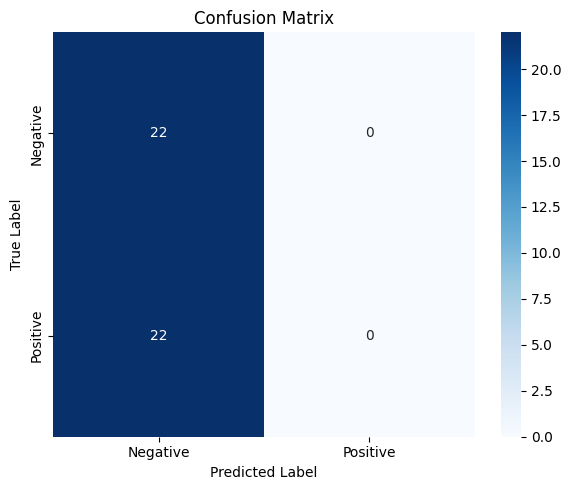

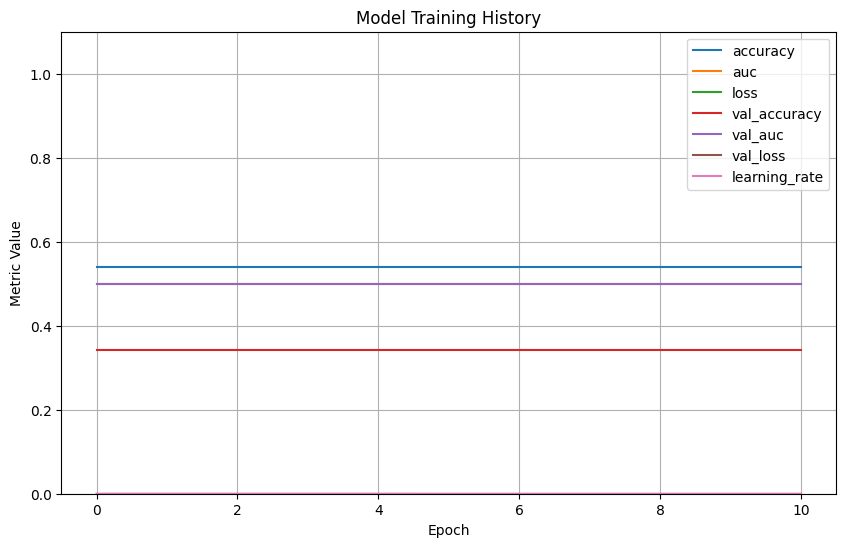

In [6]:
# -*- coding: utf-8 -*-
"""
Sudden Cardiac Death Prediction using a 1D CNN on Raw ECG Segments.

This script loads raw ECG segments preceding SCD events from the SDDB database,
trains a 1D Convolutional Neural Network (CNN) with example optimized
hyperparameters, and evaluates its performance.

Author: [Your Name/Lab Name]
Date: 2025-05-01
Version: 1.0 (CNN Approach)
"""

import os
import numpy as np
import pandas as pd
import wfdb
import joblib # For saving scaler
import logging # For structured logging
import random
import subprocess
from datetime import datetime

# Scikit-learn imports
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Imbalanced-learn import
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras imports for CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Plotting imports
import matplotlib.pyplot as plt
import seaborn as sns


# --- Configuration ---
CONFIG = {
    "data": {
        "data_dir": '/content/drive/MyDrive/sddb', # Mount Drive if using Colab
        "db_name": "sddb",
        "fs": 250,
        "window_minutes": 10, # Using 10 minutes as before
        "neg_offsets_min": [5, 10, 15],
        "pos_offsets_min": [1, 2, 3],
        "min_segment_len_sec": 60, # Minimum acceptable segment length
        "ecg_channel": 0,
        "event_annotations": ('V', 'F'), # Ventricular Ectopic, Ventricular Fibrillation Start
        # Calculated field: exact samples needed per window
        "window_samples": 10 * 60 * 250, # 10 min * 60 sec/min * 250 Hz
    },
    "preprocessing": {
        "test_size": 0.2,
        "use_smote": True,
        "smote_sampling_strategy": 'auto', # Or adjust minority ratio if needed
    },
    "modeling": {
        # Example Optimized Hyperparameters for the CNN
        # These would ideally be found using Keras Tuner / Optuna
        "cnn_filters": [64, 128, 128, 256], # Number of filters per conv layer
        "cnn_kernel_sizes": [15, 10, 10, 5], # Kernel sizes per conv layer
        "cnn_pool_sizes": [3, 3, 3, 3], # Pool sizes after each conv layer
        "cnn_dropout_rate": 0.4, # Dropout rate for regularization
        "dense_units": 128, # Units in the dense layer before output
        "learning_rate": 0.0001, # Initial learning rate for Adam optimizer
        "batch_size": 32, # Training batch size
        "epochs": 100, # Maximum number of epochs (Early Stopping will likely halt earlier)
    },
    "training": {
         "early_stopping_patience": 10, # Patience for EarlyStopping
         "reduce_lr_patience": 5, # Patience for ReduceLROnPlateau
         "reduce_lr_factor": 0.2, # Factor to reduce LR by
    },
    "evaluation": {
        "plot_confusion_matrix": True,
        "plot_training_history": True,
    },
    "experiment": {
        "random_state": 42,
        "log_level": logging.INFO, # Set to DEBUG for more verbose output
        "save_results": True, # Flag to control saving
        "results_dir": "./scd_prediction_cnn_results", # Directory to save outputs
        "run_timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
    }
}

# --- Logging Setup ---
logging.basicConfig(level=CONFIG["experiment"]["log_level"],
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    datefmt='%Y-%m-%d %H:%M:%S')

# --- Reproducibility ---
def set_seed(seed):
    """Sets random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Optional: For GPU determinism (might impact performance)
    # os.environ['TF_DETERMINISTIC_OPS'] = '1'
    # os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    logging.info(f"Random seed set to {seed}")

set_seed(CONFIG["experiment"]["random_state"])

# --- Helper Functions ---
def ensure_dir_exists(dir_path):
    """Creates a directory if it doesn't exist."""
    if not os.path.isdir(dir_path):
        os.makedirs(dir_path, exist_ok=True)
        logging.info(f"Created directory: {dir_path}")

def download_data(db_name, output_dir):
    """Downloads PhysioNet database if the specified directory doesn't exist."""
    if not os.path.isdir(output_dir) or not os.listdir(output_dir):
        logging.info(f"Data directory '{output_dir}' not found or empty. Downloading {db_name}...")
        ensure_dir_exists(os.path.dirname(output_dir))
        try:
             # Use os.system for simplicity here, or subprocess for more control
             os.system('pip install wfdb physionet-client -q')
             os.system(f'physionet-client download {db_name} --output {output_dir}')
             logging.info(f"{db_name} download complete to {output_dir}.")
        except Exception as e:
            logging.error(f"Error during download or command execution: {e}", exc_info=True)
            raise RuntimeError(f"Failed to download database {db_name}.")
    else:
        logging.info(f"Data directory '{output_dir}' found.")


# --- Data Loading for CNN ---
def load_record_data(record_path):
    """Loads signal and annotations for a single record."""
    try:
        record = wfdb.rdrecord(record_path)
        annotation = wfdb.rdann(record_path, 'atr')
        return record, annotation
    except Exception as e:
        logging.warning(f"Skipping record {os.path.basename(record_path)} due to reading error: {e}")
        return None, None

def extract_segments_for_record(record, annotation, config):
    """Extracts raw ECG segments for all relevant windows from a single record."""
    segments_list = []
    labels_list = []
    cfg_data = config['data']
    signal = record.p_signal[:, cfg_data['ecg_channel']]
    samples, symbols = annotation.sample, annotation.symbol
    event_samples = sorted([s for s, sym in zip(samples, symbols) if sym in cfg_data['event_annotations']])
    fs = cfg_data['fs']
    target_len = cfg_data['window_samples'] # Target length for CNN input

    if not event_samples: return [], []

    for event_sample in event_samples[-3:]: # Process last 3 events
        # Positive windows
        for minutes_before in cfg_data['pos_offsets_min']:
            offset_samples = minutes_before * 60 * fs
            end = event_sample - offset_samples
            start = max(0, end - target_len)
            segment = signal[start:end]
            # Pad if segment is shorter than target_len (e.g., near start of recording)
            if len(segment) < target_len:
                pad_width = target_len - len(segment)
                segment = np.pad(segment, (pad_width, 0), 'constant', constant_values=0) # Pad at the beginning
            # Ensure segment is exactly target_len (should be handled by start/end/padding)
            if len(segment) == target_len:
                 segments_list.append(segment)
                 labels_list.append(1)
            else:
                 logging.debug(f"Skipping positive segment for event {event_sample} offset {minutes_before}: Incorrect length {len(segment)}")


        # Negative windows
        for minutes_before in cfg_data['neg_offsets_min']:
            offset_samples = minutes_before * 60 * fs
            end = event_sample - target_len - offset_samples # Window ends further away
            start = max(0, end - target_len)
            segment = signal[start:end]
            if len(segment) < target_len:
                pad_width = target_len - len(segment)
                segment = np.pad(segment, (pad_width, 0), 'constant', constant_values=0)
            if len(segment) == target_len:
                segments_list.append(segment)
                labels_list.append(0)
            else:
                logging.debug(f"Skipping negative segment for event {event_sample} offset {minutes_before}: Incorrect length {len(segment)}")

    return segments_list, labels_list

def load_all_segments(config):
    """Loads all records, extracts raw ECG segments, and returns arrays."""
    logging.info("Starting raw ECG segment extraction from all records...")
    all_segments = []
    all_labels = []
    data_dir = config['data']['data_dir']
    record_files = [f[:-4] for f in os.listdir(data_dir) if f.endswith('.dat')]
    processed_count = 0

    for rec_name in record_files:
        rec_path = os.path.join(data_dir, rec_name)
        if not os.path.isfile(rec_path + '.atr'): continue # Skip if annotation missing

        record, annotation = load_record_data(rec_path)
        if record and annotation:
            record_segments, record_labels = extract_segments_for_record(record, annotation, config)
            all_segments.extend(record_segments)
            all_labels.extend(record_labels)
        processed_count += 1
        if processed_count % 10 == 0:
             logging.debug(f"Processed {processed_count}/{len(record_files)} records...")

    logging.info(f"Finished segment extraction. Total segments extracted: {len(all_segments)}")
    if not all_segments:
        logging.error("No segments extracted. Check data or configuration.")
        return np.array([]), np.array([]) # Return empty arrays

    X = np.array(all_segments)
    y = np.array(all_labels)
    logging.info(f"Created data arrays: X shape={X.shape}, y shape={y.shape}")
    return X, y


# --- Data Preprocessing for CNN Modeling ---
def prepare_cnn_data(X, y, config):
    """Splits, scales, reshapes, and optionally applies SMOTE to the data for CNN."""
    if X.size == 0 or y.size == 0:
        logging.error("Cannot prepare modeling data: Input arrays are empty.")
        return None, None, None, None, None

    logging.info("Preparing data for CNN modeling...")
    cfg_prep = config['preprocessing']
    cfg_exp = config['experiment']
    cfg_data = config['data']
    target_len = cfg_data['window_samples']

    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=cfg_prep['test_size'],
        stratify=y,
        random_state=cfg_exp['random_state']
    )
    logging.info(f"Data split: Train={X_train.shape}, Test={X_test.shape}")
    logging.info(f"Train class distribution: {np.bincount(y_train)}")
    logging.info(f"Test class distribution: {np.bincount(y_test)}")


    # Scale Features (Important: Scale each sample independently or fit on training data)
    # Fit scaler ONLY on training data to prevent leakage
    # Reshape for scaler: (n_samples, n_features=target_len)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, target_len)).reshape(-1, target_len, 1)
    X_test_scaled = scaler.transform(X_test.reshape(-1, target_len)).reshape(-1, target_len, 1)

    logging.info("ECG segments scaled using StandardScaler.")
    logging.info(f"Data reshaped for CNN: Train={X_train_scaled.shape}, Test={X_test_scaled.shape}")

    # Apply SMOTE (Optional) - Apply *after* scaling, *before* reshaping for SMOTE
    # SMOTE expects 2D input: (n_samples, n_features)
    if cfg_prep['use_smote']:
        logging.info(f"Applying SMOTE to training data. Distribution before: {pd.Series(y_train).value_counts().to_dict()}")
        smote = SMOTE(random_state=cfg_exp['random_state'], sampling_strategy=cfg_prep['smote_sampling_strategy'])
        # Reshape train data for SMOTE
        X_train_reshaped_for_smote = X_train_scaled.reshape(X_train_scaled.shape[0], -1)

        try:
            X_train_resampled, y_train_resampled = smote.fit_resample(X_train_reshaped_for_smote, y_train)
            logging.info(f"Distribution after SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")
            # Reshape back for CNN: (n_samples, sequence_length, 1)
            X_train_final = X_train_resampled.reshape(-1, target_len, 1)
            y_train_final = y_train_resampled
            logging.info(f"Training data shape after SMOTE and reshape: {X_train_final.shape}")
        except ValueError as e:
             logging.error(f"SMOTE failed: {e}. This might happen if a class has very few samples. Skipping SMOTE.")
             X_train_final = X_train_scaled
             y_train_final = y_train

    else:
        X_train_final = X_train_scaled
        y_train_final = y_train
        logging.info("SMOTE not applied.")

    return X_train_final, y_train_final, X_test_scaled, y_test, scaler


# --- Model Building ---
def build_cnn_model(input_shape, config):
    """Builds the 1D CNN model based on configuration."""
    logging.info("Building 1D CNN model...")
    cfg_model = config['modeling']

    model = Sequential(name="SCD_Prediction_CNN")
    model.add(Input(shape=input_shape)) # Use Input layer

    # Add convolutional blocks
    for i in range(len(cfg_model['cnn_filters'])):
        model.add(Conv1D(filters=cfg_model['cnn_filters'][i],
                         kernel_size=cfg_model['cnn_kernel_sizes'][i],
                         activation='relu',
                         padding='same')) # Use 'same' padding initially
        model.add(BatchNormalization()) # Add Batch Normalization
        model.add(MaxPooling1D(pool_size=cfg_model['cnn_pool_sizes'][i]))
        # Optional: Add dropout within conv blocks if needed, but often placed before dense layers
        # model.add(Dropout(cfg_model['cnn_dropout_rate'] / 2)) # Example: Smaller dropout here

    # Flatten and Dense layers
    model.add(Flatten())
    model.add(Dropout(cfg_model['cnn_dropout_rate'])) # Main dropout before dense
    model.add(Dense(cfg_model['dense_units'], activation='relu'))
    model.add(BatchNormalization()) # Batch Norm before final output activation
    model.add(Dropout(cfg_model['cnn_dropout_rate'] / 2 )) # Optional smaller dropout
    model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification

    # Compile model
    optimizer = Adam(learning_rate=cfg_model['learning_rate'])
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]) # Add AUC metric

    logging.info("CNN model built successfully.")
    model.summary(print_fn=logging.info) # Log model summary
    return model

# --- Training and Evaluation ---
def train_evaluate_cnn(model, X_train, y_train, X_test, y_test, config):
    """Trains the CNN model, evaluates it, and logs/plots results."""
    logging.info("--- Starting CNN Model Training ---")
    cfg_model = config['modeling']
    cfg_train = config['training']
    cfg_eval = config['evaluation']
    cfg_exp = config['experiment']
    results_dir = cfg_exp["results_dir"]
    run_ts = cfg_exp["run_timestamp"]
    ensure_dir_exists(results_dir)


    # Callbacks for optimization and preventing overfitting
    early_stopping = EarlyStopping(monitor='val_auc', # Monitor validation AUC
                                   patience=cfg_train['early_stopping_patience'],
                                   mode='max', # Maximize AUC
                                   restore_best_weights=True, # Restore best model found
                                   verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                  factor=cfg_train['reduce_lr_factor'],
                                  patience=cfg_train['reduce_lr_patience'],
                                  min_lr=1e-7, # Don't reduce LR below this
                                  verbose=1)

    start_time = datetime.now()
    history = model.fit(X_train, y_train,
                        epochs=cfg_model['epochs'],
                        batch_size=cfg_model['batch_size'],
                        validation_split=0.2, # Use part of training data for validation during training
                        callbacks=[early_stopping, reduce_lr],
                        verbose=1) # Set to 1 or 2 for progress updates
    end_time = datetime.now()
    logging.info(f"Training complete. Duration: {end_time - start_time}")
    logging.info(f"Training stopped after {len(history.history['loss'])} epochs.")


    logging.info("--- Evaluating Model on Test Set ---")
    loss, accuracy, auc = model.evaluate(X_test, y_test, verbose=0)
    logging.info(f"Test Loss: {loss:.4f}")
    logging.info(f"Test Accuracy: {accuracy*100:.2f}%")
    logging.info(f"Test AUC: {auc:.4f}")

    # Get detailed predictions for classification report and confusion matrix
    y_pred_prob = model.predict(X_test).flatten() # Get probabilities
    y_pred_class = (y_pred_prob > 0.5).astype(int) # Convert probabilities to class labels

    # Classification Report
    report = classification_report(y_test, y_pred_class)
    logging.info(f"\nClassification Report:\n{report}")

    results = {
        'test_loss': loss,
        'test_accuracy': accuracy,
        'test_auc': auc,
        'classification_report': report,
        'epochs_trained': len(history.history['loss'])
    }


    # Plot Confusion Matrix (Optional)
    if cfg_eval['plot_confusion_matrix']:
        cm = confusion_matrix(y_test, y_pred_class)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.savefig(os.path.join(results_dir, f"{run_ts}_eval_confusion_matrix.png"))
        plt.show()

    # Plot Training History (Optional)
    if cfg_eval['plot_training_history']:
        pd.DataFrame(history.history).plot(figsize=(10, 6))
        plt.grid(True)
        plt.gca().set_ylim(0, max(1, np.max(history.history['accuracy']), np.max(history.history['val_accuracy'])) * 1.1) # Adjust y-axis limit
        plt.title('Model Training History')
        plt.xlabel('Epoch')
        plt.ylabel('Metric Value')
        plt.savefig(os.path.join(results_dir, f"{run_ts}_eval_training_history.png"))
        plt.show()


    # Save results
    if cfg_exp['save_results']:
        results_path = os.path.join(results_dir, f"{run_ts}_results.txt")
        with open(results_path, 'w') as f:
            f.write(f"Test Loss: {loss:.4f}\n")
            f.write(f"Test Accuracy: {accuracy*100:.2f}%\n")
            f.write(f"Test AUC: {auc:.4f}\n")
            f.write(f"Epochs Trained: {results['epochs_trained']}\n\n")
            f.write("Classification Report:\n")
            f.write(results['classification_report'])
        logging.info(f"Evaluation results saved to {results_path}")

        # Save the trained model
        model_path = os.path.join(results_dir, f"{run_ts}_cnn_model.keras") # Use .keras format
        model.save(model_path)
        logging.info(f"Trained CNN model saved to {model_path}")

    return results


# --- Main Execution ---
def main():
    """Main function to run the SCD prediction pipeline using CNN."""
    logging.info("--- Starting SCD Prediction Pipeline (CNN Approach) ---")

    # 1. Ensure data is available
    download_data(CONFIG["data"]["db_name"], CONFIG["data"]["data_dir"])

    # 2. Load raw ECG segments
    X_segments, y_labels = load_all_segments(CONFIG)
    if X_segments.size == 0:
        logging.critical("Segment array is empty. Cannot proceed.")
        return # Stop execution

    # 3. Prepare data for CNN modeling (Split, Scale, Reshape, SMOTE)
    prep_data = prepare_cnn_data(X_segments, y_labels, CONFIG)
    if prep_data is None: # Check if preparation failed
        logging.critical("Data preparation failed. Cannot proceed.")
        return
    X_train, y_train, X_test, y_test, scaler = prep_data

    # Save the scaler
    if CONFIG['experiment']['save_results']:
        results_dir = CONFIG["experiment"]["results_dir"]
        ensure_dir_exists(results_dir)
        run_ts = CONFIG["experiment"]["run_timestamp"]
        scaler_path = os.path.join(results_dir, f"{run_ts}_cnn_scaler.joblib")
        joblib.dump(scaler, scaler_path)
        logging.info(f"Scaler saved to {scaler_path}")

    # 4. Build the CNN model
    input_shape = (X_train.shape[1], X_train.shape[2]) # (sequence_length, num_channels=1)
    cnn_model = build_cnn_model(input_shape, CONFIG)

    # 5. Train and evaluate
    evaluation_results = train_evaluate_cnn(cnn_model, X_train, y_train, X_test, y_test, CONFIG)

    logging.info(f"Final Test Accuracy: {evaluation_results.get('test_accuracy', 0)*100:.2f}%")
    logging.info(f"Final Test AUC: {evaluation_results.get('test_auc', 0):.4f}")
    logging.info("--- SCD Prediction Pipeline (CNN Approach) Finished ---")

if __name__ == "__main__":
    # Check GPU availability
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            # Currently, memory growth needs to be the same across GPUs
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            logical_gpus = tf.config.list_logical_devices('GPU')
            logging.info(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs available.")
        except RuntimeError as e:
            # Memory growth must be set before GPUs have been initialized
            logging.error(e)
    else:
        logging.warning("No GPU detected by TensorFlow. Training will run on CPU.")

    # Run the main pipeline
    main()